# Notebook 09 — Đánh giá độ phức tạp Graph

Notebook này đánh giá độ phức tạp của đồ thị không đồng nhất (heterogeneous graph) đã được xây dựng ở các bước trước. Chúng ta sẽ phân tích:
1. Thống kê cơ bản (Số lượng Node, Edge)
2. Mật độ đồ thị (Graph Density)
3. Phân phối bậc (Degree Distribution)
4. Các chỉ số nâng cao qua NetworkX (Các thành phần liên thông, Hệ số cụm - Clustering Coefficient)

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from torch_geometric.utils import degree, to_networkx
from pathlib import Path

# Thiết lập style cho biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
PROCESSED_DIR = Path("../data/processed/")
data_path = PROCESSED_DIR / "hetero_data.pt"

data = torch.load(data_path, weights_only=False)
print("Dữ liệu đồ thị:\n", data)

Dữ liệu đồ thị:
 HeteroData(
  user={ x=[1642, 384] },
  item={ x=[21639, 384] },
  (user, reviews, item)={ edge_index=[2, 10751] },
  (item, also_bought, item)={ edge_index=[2, 7253] }
)


## 1. Thống kê cơ bản & Mật độ đồ thị
Tính toán số lượng node, edge và mật độ đồ thị cho cả đồ thị hai phía user-item và đồ thị đồng nhất item-item.

In [3]:
num_users = data['user'].num_nodes
num_items = data['item'].num_nodes
num_reviews = data['user', 'reviews', 'item'].edge_index.shape[1]
num_also_bought = data['item', 'also_bought', 'item'].edge_index.shape[1]

print(f"Tổng số Users: {num_users:,}")
print(f"Tổng số Items: {num_items:,}")
print(f"Tổng số cạnh 'reviews': {num_reviews:,}")
print(f"Tổng số cạnh 'also_bought': {num_also_bought:,}")

# Tính toán mật độ (Density)
# Mật độ User-Item Bipartite: E / (U * I)
ui_density = num_reviews / (num_users * num_items)
print(f"\nMật độ đồ thị Bipartite User-Item: {ui_density:.6f} ({ui_density*100:.4f}%)")

# Mật độ Item-Item: E / (I * (I - 1))
ii_density = num_also_bought / (num_items * (num_items - 1))
print(f"Mật độ đồ thị Item-Item: {ii_density:.6f} ({ii_density*100:.4f}%)")

Tổng số Users: 1,642
Tổng số Items: 21,639
Tổng số cạnh 'reviews': 10,751
Tổng số cạnh 'also_bought': 7,253

Mật độ đồ thị Bipartite User-Item: 0.000303 (0.0303%)
Mật độ đồ thị Item-Item: 0.000015 (0.0015%)


## 2. Phân phối bậc (Degree Distribution)
Phân tích phân phối bậc giúp chúng ta hiểu liệu đồ thị có tuân theo phân phối power-law (scale-free) hay không, điều này rất phổ biến trong các mạng xã hội và thương mại điện tử thực tế.

In [4]:
# Tính toán bậc
user_out_degree = degree(data['user', 'reviews', 'item'].edge_index[0], num_nodes=num_users).numpy()
item_in_degree = degree(data['user', 'reviews', 'item'].edge_index[1], num_nodes=num_items).numpy()

item_also_bought_degree = degree(data['item', 'also_bought', 'item'].edge_index[0], num_nodes=num_items).numpy()

print(f"User 'reviews' out-degree -> Min: {user_out_degree.min():.0f}, Max: {user_out_degree.max():.0f}, Trung bình: {user_out_degree.mean():.2f}")
print(f"Item 'reviews' in-degree  -> Min: {item_in_degree.min():.0f}, Max: {item_in_degree.max():.0f}, Trung bình: {item_in_degree.mean():.2f}")
print(f"Item 'also_bought' degree -> Min: {item_also_bought_degree.min():.0f}, Max: {item_also_bought_degree.max():.0f}, Trung bình: {item_also_bought_degree.mean():.2f}")

User 'reviews' out-degree -> Min: 1, Max: 52, Trung bình: 6.55
Item 'reviews' in-degree  -> Min: 0, Max: 210, Trung bình: 0.50
Item 'also_bought' degree -> Min: 0, Max: 49, Trung bình: 0.34


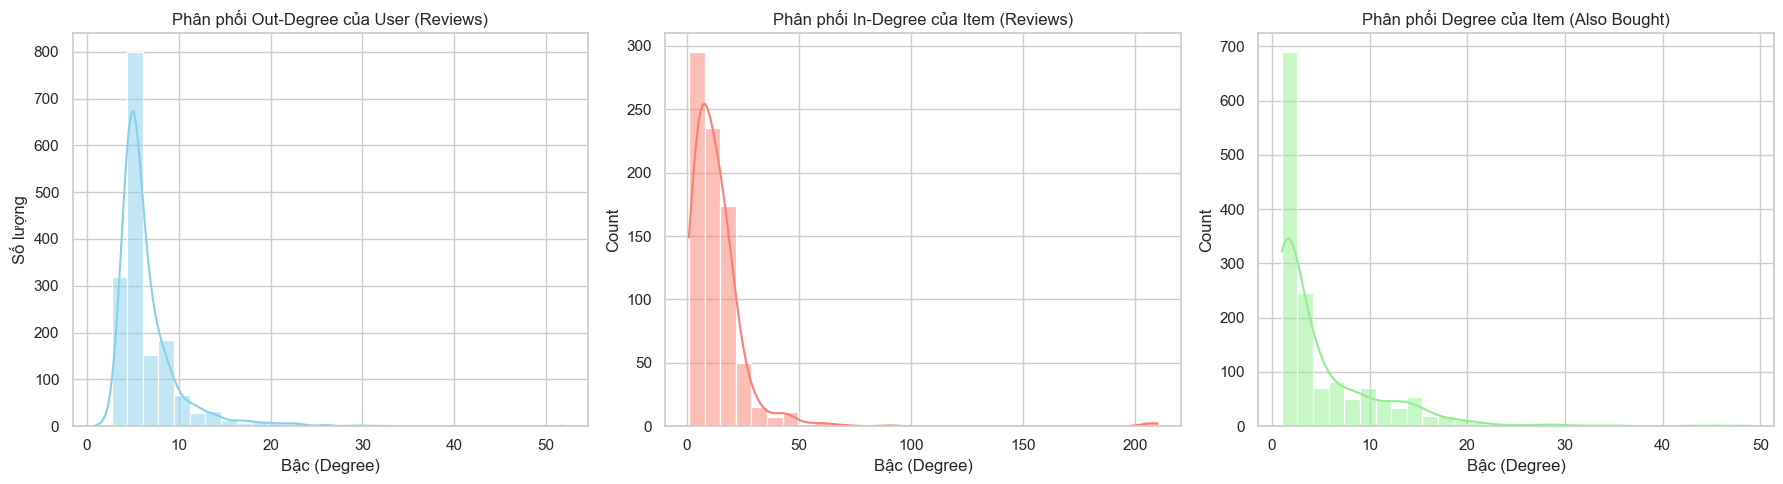

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(user_out_degree[user_out_degree > 0], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối Out-Degree của User (Reviews)')
axes[0].set_xlabel('Bậc (Degree)')
axes[0].set_ylabel('Số lượng')

sns.histplot(item_in_degree[item_in_degree > 0], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Phân phối In-Degree của Item (Reviews)')
axes[1].set_xlabel('Bậc (Degree)')

sns.histplot(item_also_bought_degree[item_also_bought_degree > 0], bins=30, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Phân phối Degree của Item (Also Bought)')
axes[2].set_xlabel('Bậc (Degree)')

plt.tight_layout()
plt.show()

## 3. Các chỉ số nâng cao với NetworkX
Chúng ta chuyển đổi đồ thị không đồng nhất thành dạng đồng nhất để tính toán hệ số cụm toàn cục (global clustering coefficient) và xác định các thành phần liên thông (connected components).

In [6]:
print("Đang chuyển đổi sang đồ thị đồng nhất...")
homo_data = data.to_homogeneous()
print(homo_data)

print("\nĐang chuyển đổi sang NetworkX...")
G = to_networkx(homo_data, to_undirected=True)
print(f"Đồ thị NetworkX đã tạo với {G.number_of_nodes()} nodes và {G.number_of_edges()} edges.")

Đang chuyển đổi sang đồ thị đồng nhất...
Data(edge_index=[2, 18004], x=[23281, 384], node_type=[23281], edge_type=[18004])

Đang chuyển đổi sang NetworkX...
Đồ thị NetworkX đã tạo với 23281 nodes và 16046 edges.


In [7]:
print("Đang tính toán các thành phần liên thông (Connected Components)...")
# Các thành phần liên thông
components = list(nx.connected_components(G))
num_components = len(components)
largest_cc = max(components, key=len)

print(f"Số lượng thành phần liên thông: {num_components}")
print(f"Kích thước của thành phần liên thông lớn nhất: {len(largest_cc)} nodes ({len(largest_cc)/G.number_of_nodes()*100:.2f}% của toàn bộ đồ thị)")

# Kiểm tra các node bị cô lập (isolated nodes)
isolated = list(nx.isolates(G))
print(f"Số lượng node bị cô lập: {len(isolated)}")

Đang tính toán các thành phần liên thông (Connected Components)...
Số lượng thành phần liên thông: 19607
Kích thước của thành phần liên thông lớn nhất: 3468 nodes (14.90% của toàn bộ đồ thị)
Số lượng node bị cô lập: 19506


In [8]:
print("Đang tính toán Hệ số Cụm (Clustering Coefficient)...")
clustering_coeff = nx.transitivity(G)
print(f"Hệ số cụm toàn cục (Transitivity): {clustering_coeff:.4f}")

avg_clustering = nx.average_clustering(G)
print(f"Hệ số cụm trung bình (Average Clustering): {avg_clustering:.4f}")

Đang tính toán Hệ số Cụm (Clustering Coefficient)...


Hệ số cụm toàn cục (Transitivity): 0.1148


Hệ số cụm trung bình (Average Clustering): 0.0259
